# Fisher Vector + Linear Classifier (Birds)

This notebook trains a classical **Fisher Vector (FV) + linear classifier** model and visualizes
how local descriptors are encoded. The implementation follows the pipeline described in
*Image Classification with the Fisher Vector: Theory and Practice*.


## Imports
We reuse helper functions from `scripts/train_fisher_vector.py` so the notebook stays consistent
with the training script.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Add repo root to sys.path for local imports
root = Path.cwd().resolve().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))


from scripts.train_fisher_vector import (
    FisherConfig,
    build_label_mapping_from_folders,
    load_labeled_paths,
    read_image_bgr,
    extract_sift_descriptors,
    sample_descriptors,
    fit_gmm,
    extract_fisher_vectors,
    build_model,
)


## Paths and configuration


In [2]:
train_dir = root / 'data' / 'train_images_cropped'
val_dir = root / 'data' / 'val_images_cropped'
outputs_dir = root / 'outputs'
cache_dir = outputs_dir / 'cache_fv'
cache_dir.mkdir(parents=True, exist_ok=True)

cfg = FisherConfig(
    img_size=320,
    dense_step=6,
    dense_size=12,
    max_per_image=1200,
    use_rootsift=True,
    n_components=256,
    random_state=42,
)


## Quick dataset sanity check


train images: 1082
classes: 20


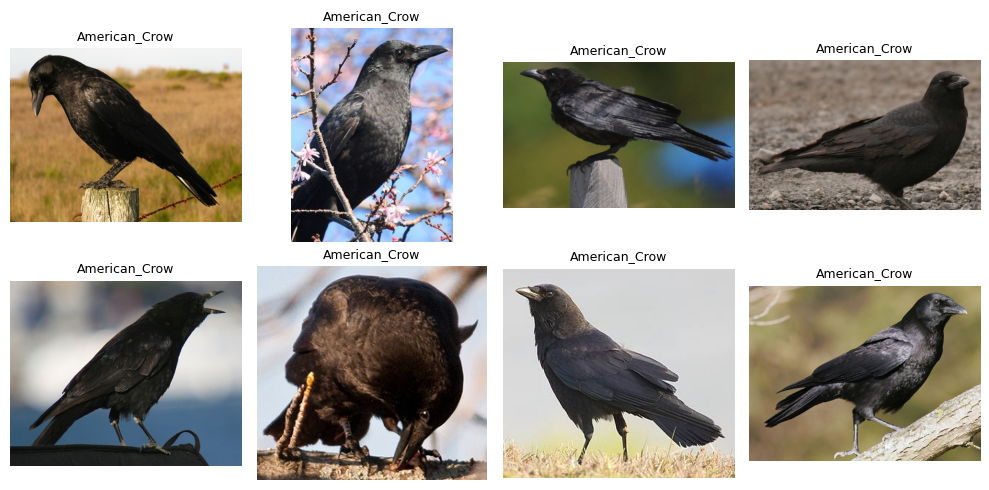

In [4]:
mapping = build_label_mapping_from_folders(train_dir)
train_paths, y_train = load_labeled_paths(train_dir, mapping)
print('train images:', len(train_paths))
print('classes:', len(mapping))

# Show a small grid of images
num_show = 8
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, p in zip(axes.ravel(), train_paths[:num_show]):
    img = cv2.cvtColor(read_image_bgr(p), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(p.parent.name, fontsize=9)
    ax.axis('off')
plt.tight_layout()


## Visualize dense SIFT keypoints (local descriptor support)


(np.float64(-0.5), np.float64(319.5), np.float64(319.5), np.float64(-0.5))

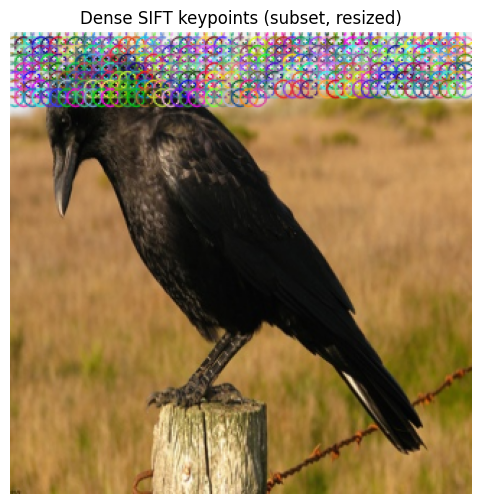

In [14]:
sample_img = read_image_bgr(train_paths[0])
resized = cv2.resize(sample_img, (cfg.img_size, cfg.img_size), interpolation=cv2.INTER_AREA)

kps, desc = extract_sift_descriptors(sample_img, cfg)
vis = cv2.drawKeypoints(resized, kps[:400], None,
                        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Dense SIFT keypoints (subset, resized)')
plt.axis('off')


## Fit GMM visual vocabulary
We fit a diagonal-covariance GMM on sampled descriptors. We can increase
`max_desc` or `n_components` for a stronger model (at a cost in time).


In [5]:
gmm_cache = cache_dir / f'gmm_k{cfg.n_components}.joblib'
if gmm_cache.exists():
    import joblib
    gmm = joblib.load(gmm_cache)
    print('loaded GMM:', gmm_cache)
else:
    desc = sample_descriptors(train_paths, cfg, max_desc=500000)
    gmm = fit_gmm(desc, n_components=cfg.n_components, random_state=cfg.random_state)
    import joblib
    joblib.dump(gmm, gmm_cache)
    print('saved GMM:', gmm_cache)


saved GMM: C:\Users\stef4\Desktop\Machine Learning\image-classification-birds\outputs\cache_fv\gmm_k256.joblib


## Encode images with Fisher Vectors and visualize embedding


(np.float64(-29.20613718032837),
 np.float64(25.23884630203247),
 np.float64(-30.297833251953126),
 np.float64(28.56253128051758))

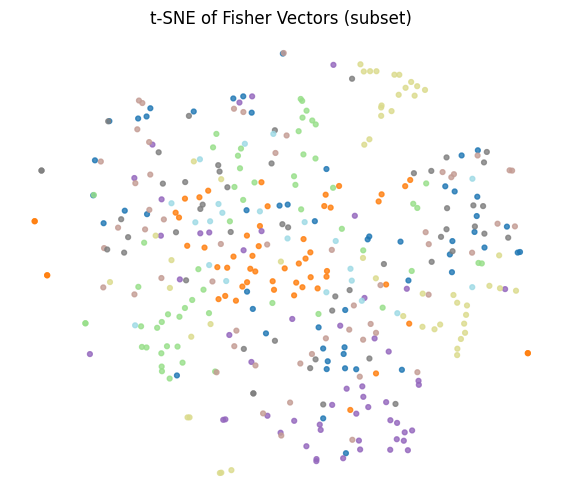

In [10]:
subset_n = 400
subset_paths = train_paths[:subset_n]
subset_labels = y_train[:subset_n]

X_sub = extract_fisher_vectors(subset_paths, cfg, gmm)
X_pca = PCA(n_components=50, random_state=cfg.random_state).fit_transform(X_sub)
X_tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=cfg.random_state).fit_transform(X_pca)

plt.figure(figsize=(7, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=subset_labels, cmap='tab20', s=12, alpha=0.8)
plt.title('t-SNE of Fisher Vectors (subset)')
plt.axis('off')


## Visualize soft-assignments (encoding map) for one image
We color each dense SIFT location by its most probable GMM component.


(np.float64(-0.5), np.float64(319.5), np.float64(319.5), np.float64(-0.5))

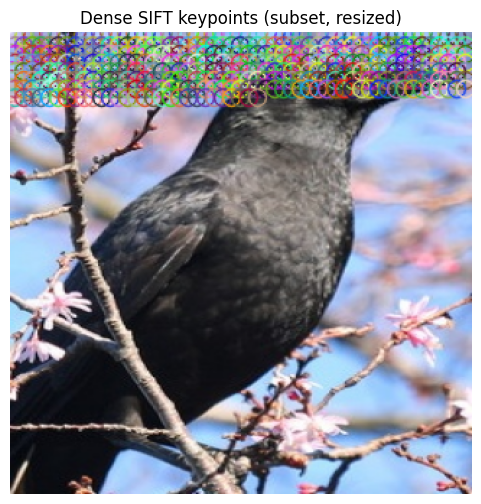

In [13]:
# Use the same resized image used for SIFT
resized = cv2.resize(sample_img, (cfg.img_size, cfg.img_size), interpolation=cv2.INTER_AREA)

kps, desc = extract_sift_descriptors(sample_img, cfg)
vis = cv2.drawKeypoints(resized, kps[:400], None,
                        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Dense SIFT keypoints (subset, resized)')
plt.axis('off')

## Train a linear classifier on Fisher Vectors


In [12]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

cache_train = cache_dir / f"fv_train_k{cfg.n_components}.npz"
X_train = extract_fisher_vectors(train_paths, cfg, gmm, cache_npz=cache_train)

# 5-fold CV on TRAIN ONLY
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accs = []

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train[tr_idx], X_train[te_idx]
    y_tr, y_te = y_train[tr_idx], y_train[te_idx]

    fold_model = build_model(classifier="linear_svm", C=1.0, max_iter=5000, use_scaler=False)
    fold_model.fit(X_tr, y_tr)

    pred_te = fold_model.predict(X_te)
    acc_te = (pred_te == y_te).mean()
    cv_accs.append(acc_te)
    print(f"[CV fold {fold}] acc={acc_te:.4f}")

cv_accs = np.array(cv_accs, dtype=float)
print(f"train 5-fold CV acc: {cv_accs.mean():.4f} ± {cv_accs.std(ddof=1):.4f}")

# Train final model on FULL TRAIN
model = build_model(classifier="linear_svm", C=1.0, max_iter=5000, use_scaler=False)
model.fit(X_train, y_train)

# Evaluate on VAL if available
if val_dir.exists():
    val_paths, y_val = load_labeled_paths(val_dir, mapping)
    cache_val = cache_dir / f"fv_val_k{cfg.n_components}.npz"
    X_val = extract_fisher_vectors(val_paths, cfg, gmm, cache_npz=cache_val)

    pred = model.predict(X_val)
    acc = (pred == y_val).mean()
    print(f"val acc: {acc:.4f}")
else:
    print("No val folder found; model trained on train set only.")


[CV fold 1] acc=0.4516
[CV fold 2] acc=0.3779
[CV fold 3] acc=0.3241
[CV fold 4] acc=0.3565
[CV fold 5] acc=0.4074
train 5-fold CV acc: 0.3835 ± 0.0487
val acc: 0.3592
